# Overblik over projektets logik

1. **Først sættes notebooken op**, fordi projektet skal bruge biblioteker, filstier, konstanter, billedstørrelse, batch size, seed og performance-indstillinger, før data eller modeller kan bruges.
   **Hører til: Kapitel 1**

2. **Derefter indlæses og opdeles billeddatasættet**, fordi modellen skal bruge adskilte data til træning, validering, kalibrering og endelig test. Træningsdata shuffles før split, så validation- og kalibreringssæt bliver mere repræsentative.
   **Hører til: Kapitel 1**

3. **Derefter kontrolleres klassebalancen**, fordi modellens accuracy kun er meningsfuld, hvis Horse- og Human-billederne er nogenlunde balancerede på tværs af train, validation, kalibrering og test.
   **Hører til: Kapitel 2**

4. **Derefter oprettes en baseline CNN-model**, fordi projektet skal have en enkel startmodel, som senere forbedringer kan sammenlignes med.
   **Hører til: Kapitel 3**

5. **Derefter undersøges baseline-modellens læringskurver**, fordi accuracy og loss viser, om modellen lærer stabilt, underfitter eller overfitter.
   **Hører til: Kapitel 3**

6. **Derefter evalueres baseline-modellen på usete data**, både med standardthreshold `0.5` og med en threshold valgt på kalibreringssættet. Det holder validation-data fri til modelvalg og testdata fri til endelig evaluering.
   **Hører til: Kapitel 4**

7. **Derefter analyseres baseline-modellens fejl**, fordi samlet accuracy ikke forklarer, hvilken klasse modellen har sværest ved, eller hvilke fejltyper den laver.
   **Hører til: Kapitel 4**

8. **Derefter introduceres hyperparameter-tuning**, fordi målet er at forbedre baseline-modellen kontrolleret i stedet for at gætte bedre indstillinger manuelt.
   **Hører til: Kapitel 5**

9. **Derefter udføres broad tuning eller et cached broad-resultat bruges**, fordi notebooken først skal finde et fornuftigt område for modelindstillinger som augmentation, CNN-størrelse, dropout, dense units og learning rate.
   **Hører til: Kapitel 5.1**

10. **Derefter udføres refined tuning**, fordi broad-resultatet giver et udgangspunkt, og refined search kan søge tættere omkring de bedste indstillinger.
    **Hører til: Kapitel 5.2**

11. **Derefter vises de bedste tuning-resultater**, fordi projektet skal forklare, hvilke hyperparametre der blev valgt, og hvorfor den endelige tuned model blev valgt.
    **Hører til: Kapitel 5.3**

12. **Derefter trænes eller indlæses den endelige tuned model og evalueres**, hvor threshold vælges på kalibreringssættet og først derefter anvendes på test-sættet.
    **Hører til: Kapitel 5**

13. **Til sidst analyseres den tuned models fejl igen**, fordi tuning kan ændre fejlretningen, og en lav validation loss eller god kalibreringsscore ikke i sig selv beviser bedre test-generalisering.
    **Hører til: Kapitel 5**


# Kapitel 1 — Problemdefinition og datasæt-setup

## Formål

Dette notebook arbejder med **Horses or Humans**-datasættet. Opgaven er en **binær billedklassifikation**, hvor modellen skal afgøre, om et billede viser en **hest** eller et **menneske**.

## Klassifikationsproblem

| Punkt | Beskrivelse |
|---|---|
| Problemtype | Binær klassifikation |
| Input | RGB-billeder |
| Output | `Horse` eller `Human` |
| Datasætkilde | TensorFlow Datasets: `horses_or_humans` |

## Hvorfor bruger vi en CNN?

En CNN er velegnet til billeddata, fordi den bevarer billedets rumlige struktur. Modellen kan lære lokale mønstre som kanter, former, teksturer og objektdele, før disse kombineres til en samlet klassifikation.

I dette kapitel gør vi datasættet klar til resten af workflowet: imports, faste konstanter, indlæsning, klassenavne, metadata og eksempelbilleder.


In [99]:
%%bash
PYBIN=/home/j_hop/tf-gpu/bin/python
VENV=/home/j_hop/tf-gpu

pushd $($PYBIN -c 'import tensorflow, os; print(os.path.dirname(tensorflow.__file__))')
ln -svf ../nvidia/*/lib/*.so* .
popd

ln -sf $(find $($PYBIN -c 'import nvidia.cuda_nvcc, os; print(os.path.dirname(os.path.dirname(nvidia.cuda_nvcc.__file__)))')/*/bin/ -name ptxas -print -quit) $VENV/bin/ptxas

2026-05-18 12:10:18.236586: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-18 12:10:18.326903: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-18 12:10:19.839263: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


~/tf-gpu/lib/python3.12/site-packages/tensorflow /mnt/c/Users/J_Hop/PycharmProjects/CNN/models
'./libcublas.so.12' -> '../nvidia/cublas/lib/libcublas.so.12'
'./libcublasLt.so.12' -> '../nvidia/cublas/lib/libcublasLt.so.12'
'./libnvblas.so.12' -> '../nvidia/cublas/lib/libnvblas.so.12'
'./libcheckpoint.so' -> '../nvidia/cuda_cupti/lib/libcheckpoint.so'
'./libcupti.so.12' -> '../nvidia/cuda_cupti/lib/libcupti.so.12'
'./libnvperf_host.so' -> '../nvidia/cuda_cupti/lib/libnvperf_host.so'
'./libnvperf_target.so' -> '../nvidia/cuda_cupti/lib/libnvperf_target.so'
'./libpcsamplingutil.so' -> '../nvidia/cuda_cupti/lib/libpcsamplingutil.so'
'./libnvrtc-builtins.alt.so.12.9' -> '../nvidia/cuda_nvrtc/lib/libnvrtc-builtins.alt.so.12.9'
'./libnvrtc-builtins.so.12.9' -> '../nvidia/cuda_nvrtc/lib/libnvrtc-builtins.so.12.9'
'./libnvrtc.alt.so.12' -> '../nvidia/cuda_nvrtc/lib/libnvrtc.alt.so.12'
'./libnvrtc.so.12' -> '../nvidia/cuda_nvrtc/lib/libnvrtc.so.12'
'./libcudart.so.12' -> '../nvidia/cuda_runtime/

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<frozen posixpath>", line 181, in dirname
TypeError: expected str, bytes or os.PathLike object, not NoneType


In [100]:
# Grundlæggende biblioteker
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras

import matplotlib.pyplot as plt

# Sørger for at plots vises direkte i notebooket
%matplotlib inline

import sys
print(sys.executable)
print("TensorFlow-version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("GPU tilgængelig:", len(tf.config.list_physical_devices("GPU")) > 0)


/home/j_hop/tf-gpu/bin/python
TensorFlow-version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU tilgængelig: True


In [101]:
# Fælles konstanter for notebooket
SEED = 42
BATCH_SIZE = 32
IMG_SIZE_HH = 150
ORIGINAL_IMG_SIZE_HH = (300, 300)
CHANNELS = 3
AUTOTUNE = tf.data.AUTOTUNE

# Cache/toggle for baseline-modellen
# Sæt FORCE_RETRAIN_BASELINE_HH = True, hvis baseline-modellen skal trænes igen.
# Hvis modellen og historikken allerede findes i cache, bliver de indlæst i stedet for at træne igen.
FORCE_RETRAIN_BASELINE_HH = False
BASELINE_CACHE_DIR_HH = Path("model_cache") / "horses_or_humans"
BASELINE_MODEL_PATH_HH = BASELINE_CACHE_DIR_HH / "baseline_cnn_hh.keras"
BASELINE_HISTORY_PATH_HH = BASELINE_CACHE_DIR_HH / "history_baseline_hh.csv"
BASELINE_CACHE_DIR_HH.mkdir(parents=True, exist_ok=True)

# Tip til Google Colab:
# Hvis cachen skal overleve en ny runtime, kan BASELINE_CACHE_DIR_HH ændres til en mappe på Google Drive.

# Fast seed gør resultaterne mere reproducerbare
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Seed sat til:", SEED)
print("Batch size:", BATCH_SIZE)
print("Model-billedstørrelse:", IMG_SIZE_HH, "x", IMG_SIZE_HH, "x", CHANNELS)
print("Baseline-cache:", BASELINE_CACHE_DIR_HH)
print("Force retrain baseline:", FORCE_RETRAIN_BASELINE_HH)


Seed sat til: 42
Batch size: 32
Model-billedstørrelse: 150 x 150 x 3
Baseline-cache: model_cache/horses_or_humans
Force retrain baseline: False


In [102]:
# Indlæs Horses or Humans fra TensorFlow Datasets
# Vi indlæser train samlet, så vi selv kan shuffle før vi splitter i train/validation
(full_train_hh_raw, test_hh_raw), info_hh = tfds.load(
    name="horses_or_humans",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Fast seed gør splittet reproducerbart
SEED = 42

# Antal billeder i TFDS train-splittet
train_total_hh = info_hh.splits["train"].num_examples

# 60/15/15 split af train-sættet
val_size_hh = int(train_total_hh * 0.15)
calibration_size_hh = int(train_total_hh * 0.15)
train_size_hh = train_total_hh - val_size_hh - calibration_size_hh

# Shuffle før split, så validation ikke bare bliver de sidste 20% i TFDS-rækkefølgen
full_train_hh_raw = full_train_hh_raw.shuffle(
    buffer_size=train_total_hh,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Lav validation først og train bagefter
val_hh_raw = full_train_hh_raw.take(val_size_hh)

calibration_hh_raw = (
    full_train_hh_raw
    .skip(val_size_hh)
    .take(calibration_size_hh)
)

train_hh_raw = (
    full_train_hh_raw
    .skip(val_size_hh + calibration_size_hh)
)

# Klassenavne hentes fra dataset-metadata, så label-rækkefølgen passer til datasættet
raw_class_names_hh = list(info_hh.features["label"].names)

class_names_hh = [name.replace("_", " ").title() for name in raw_class_names_hh]

# Gør de viste navne mere læsevenlige, hvis TFDS bruger flertalsformer
class_names_hh = [
    "Horse" if name.lower() in ["horses", "horse"] else
    "Human" if name.lower() in ["humans", "human"] else
    name
    for name in class_names_hh
]

num_classes_hh = len(class_names_hh)

print("Klassenavne:", class_names_hh)
print("Antal klasser:", num_classes_hh)

print("Train size:", train_size_hh)
print("Validation size:", val_size_hh)
print("Calibration size:", calibration_size_hh)
print("Test size:", info_hh.splits["test"].num_examples)

Klassenavne: ['Horse', 'Human']
Antal klasser: 2
Train size: 719
Validation size: 154
Calibration size: 154
Test size: 256


In [103]:
# Grundlæggende metadata for datasættet
metadata_hh = pd.DataFrame({
    "Punkt": [
        "Datasæt",
        "Kilde",
        "Opgavetype",
        "Antal klasser",
        "Klassenavne",
        "Original billedstørrelse",
        "RGB-kanaler",
        "Model-billedstørrelse",
        "Træningseksempler",
        "Valideringseksempler",
        "Testeksempler"
    ],
    "Værdi": [
        "Horses or Humans",
        "TensorFlow Datasets",
        "Binær klassifikation",
        num_classes_hh,
        ", ".join(class_names_hh),
        f"{ORIGINAL_IMG_SIZE_HH[0]} x {ORIGINAL_IMG_SIZE_HH[1]}",
        CHANNELS,
        f"{IMG_SIZE_HH} x {IMG_SIZE_HH} x {CHANNELS}",
        tf.data.experimental.cardinality(train_hh_raw).numpy(),
        tf.data.experimental.cardinality(val_hh_raw).numpy(),
        tf.data.experimental.cardinality(test_hh_raw).numpy()
    ]
})

display(metadata_hh)

,Punkt,Værdi
0,Datasæt,Horses or Humans
1,Kilde,TensorFlow Datasets
2,Opgavetype,Binær klassifikation
3,Antal klasser,2
4,Klassenavne,"Horse, Human"
5,Original billedstørrelse,300 x 300
6,RGB-kanaler,3
7,Model-billedstørrelse,150 x 150 x 3
8,Træningseksempler,719
9,Valideringseksempler,154


In [104]:
# Dataset pipelines til resten af notebooket
# Selve resizing/rescaling laves senere i model/preprocessing-laget
train_hh = (
    train_hh_raw
    .shuffle(buffer_size=10_000, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_hh = (
    val_hh_raw
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_hh = (
    test_hh_raw
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

calibration_hh = (
    calibration_hh_raw
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

for images, labels in train_hh.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Første labels:", labels.numpy()[:10])

Batch image shape: (32, 300, 300, 3)
Batch label shape: (32,)
Image dtype: <dtype: 'uint8'>
Første labels: [0 1 0 0 1 1 1 0 1 1]


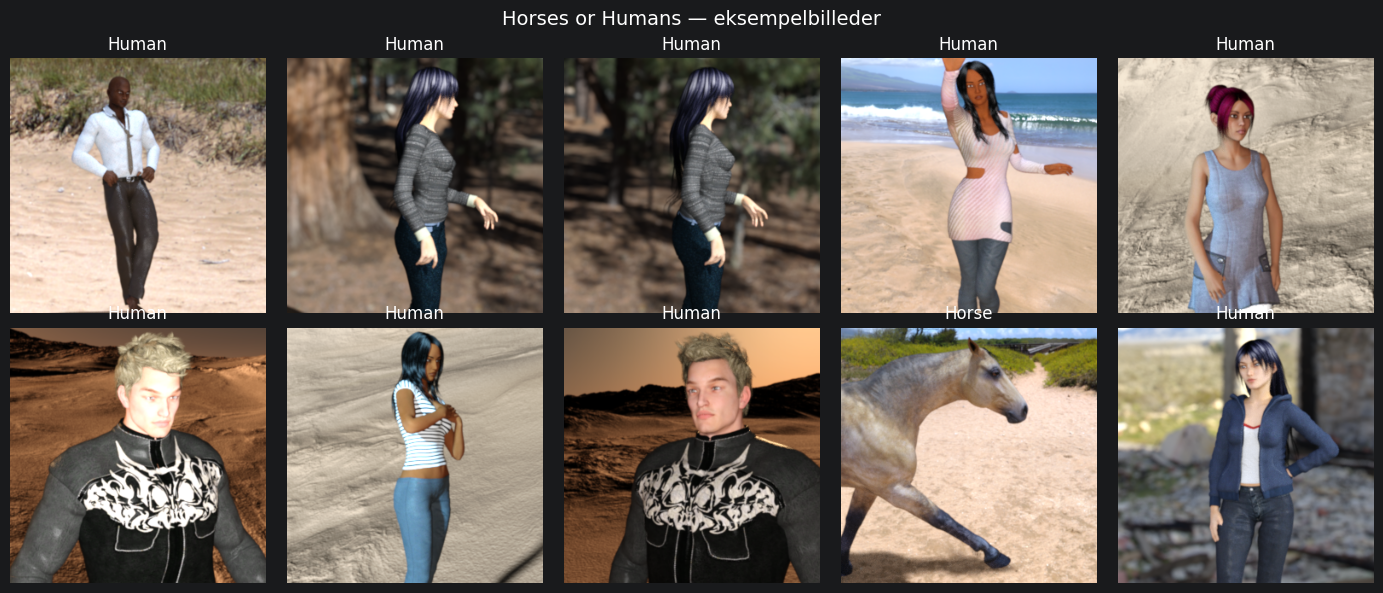

In [105]:
# Vis eksempelbilleder og deres labels
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Horses or Humans — eksempelbilleder", fontsize=14)

for images, labels in train_hh.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.set_title(class_names_hh[int(labels[i].numpy())])
        ax.axis("off")

plt.tight_layout()
plt.show()

# Kapitel 2 — Datasætanalyse og split-validering

## Formål

I dette kapitel undersøger vi, om datasættet er balanceret, og om train/validation/test-splittet er rimeligt.

For **Horses or Humans** fokuserer vi især på fordelingen mellem:

- `Horse`
- `Human`

En balanceret klassefordeling gør accuracy lettere at fortolke. Hvis én klasse dominerer, kan en model få høj accuracy uden reelt at lære begge klasser godt.

## Første visuelle observation

Eksempelbillederne fra Kapitel 1 viser, at heste og mennesker ofte er visuelt tydeligt forskellige. Det gør datasættet relativt simpelt sammenlignet med datasæt, hvor klasserne ligner hinanden mere. Derfor forventer vi, at en CNN-baseline kan lære brugbare mønstre forholdsvis hurtigt.


In [106]:
# Funktion til at tælle labels i et ubatchet TensorFlow dataset
# train_hh_raw, val_hh_raw, calibration_hh_raw og test_hh_raw blev oprettet i Kapitel 1

def count_labels_unbatched(dataset, class_names):
    counts = np.zeros(len(class_names), dtype=int)

    for _, label in dataset:
        counts[int(label.numpy())] += 1

    return counts


train_counts_hh = count_labels_unbatched(train_hh_raw, class_names_hh)
val_counts_hh = count_labels_unbatched(val_hh_raw, class_names_hh)
calibration_counts_hh = count_labels_unbatched(calibration_hh_raw, class_names_hh)
test_counts_hh = count_labels_unbatched(test_hh_raw, class_names_hh)
total_counts_hh = train_counts_hh + val_counts_hh + calibration_counts_hh + test_counts_hh

class_distribution_hh = pd.DataFrame({
    "Klasse": class_names_hh,
    "Total": total_counts_hh,
    "Træning": train_counts_hh,
    "Validering": val_counts_hh,
    "Kalibrering": calibration_counts_hh,
    "Test": test_counts_hh,
})

# Procentfordeling gør det lettere at se, om klasserne fordeles rimeligt i hvert split
class_distribution_hh["Total %"] = (class_distribution_hh["Total"] / class_distribution_hh["Total"].sum() * 100).round(2)
class_distribution_hh["Træning %"] = (class_distribution_hh["Træning"] / class_distribution_hh["Træning"].sum() * 100).round(2)
class_distribution_hh["Validering %"] = (class_distribution_hh["Validering"] / class_distribution_hh["Validering"].sum() * 100).round(2)
class_distribution_hh["Kalibrering %"] = (class_distribution_hh["Kalibrering"] / class_distribution_hh["Kalibrering"].sum() * 100).round(2)
class_distribution_hh["Test %"] = (class_distribution_hh["Test"] / class_distribution_hh["Test"].sum() * 100).round(2)

display(class_distribution_hh)

,Klasse,Total,Træning,Validering,Kalibrering,Test,Total %,Træning %,Validering %,Kalibrering %,Test %
0,Horse,628,345,78,77,128,48.95,47.98,50.65,50.0,50.0
1,Human,655,374,76,77,128,51.05,52.02,49.35,50.0,50.0


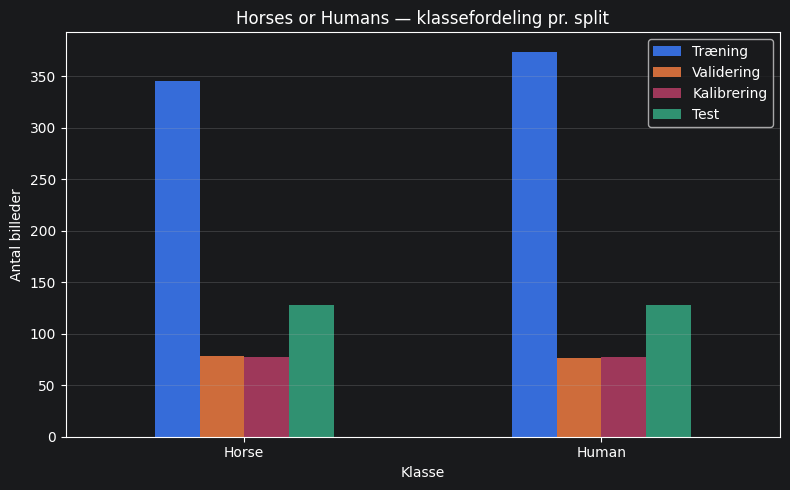

In [107]:
# Visualisering af klassernes fordeling i hvert split
plot_data_hh = class_distribution_hh.set_index("Klasse")[["Træning", "Validering", "Kalibrering", "Test"]]

ax = plot_data_hh.plot(kind="bar", figsize=(8, 5))
plt.title("Horses or Humans — klassefordeling pr. split")
plt.xlabel("Klasse")
plt.ylabel("Antal billeder")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [108]:
# Kort automatisk vurdering af balance baseret på den største procentforskel mellem klasserne
# Dette erstatter ikke den manuelle vurdering, men giver en hurtig indikator.

max_total_pct_hh = class_distribution_hh["Total %"].max()
min_total_pct_hh = class_distribution_hh["Total %"].min()
imbalance_gap_hh = max_total_pct_hh - min_total_pct_hh

if imbalance_gap_hh <= 10:
    balance_note_hh = "Datasættet ser balanceret ud."
elif imbalance_gap_hh <= 25:
    balance_note_hh = "Datasættet ser noget ubalanceret ud."
else:
    balance_note_hh = "Datasættet ser klart ubalanceret ud."

print("Største procentforskel mellem klasserne:", round(imbalance_gap_hh, 2), "procentpoint")
print(balance_note_hh)


Største procentforskel mellem klasserne: 2.1 procentpoint
Datasættet ser balanceret ud.


# Kapitel 3 — Baseline CNN-model

## Formål

I dette kapitel bygger vi en simpel **baseline CNN** for **Horses or Humans**. Baseline-modellen fungerer som referencepunkt, når vi senere tester tuning og data augmentation.

## Observation fra Kapitel 2

Datasættet er næsten balanceret i den aktuelle notebook-kørsel:

| Klasse | Total | Træning | Validering | Kalibrering | Test |
|---|---:|---:|---:|---:|---:|
| Horse | 628 | 345 | 78 | 77 | 128 |
| Human | 655 | 374 | 76 | 77 | 128 |

Den største procentforskel mellem klasserne er **2,1 procentpoint**, og test-sættet er helt balanceret med 128 billeder fra hver klasse. Derfor er accuracy mere brugbar her end i et stærkt ubalanceret datasæt. Alligevel skal accuracy ikke stå alene, fordi den ikke viser, **hvilke** fejl modellen laver.

## Baseline-strategi

Baseline-modellen bruger:

- `Resizing` fra 300 × 300 til 150 × 150
- `Rescaling` fra pixelværdier `[0, 255]` til `[0, 1]`
- En CNN-arkitektur med fire convolutional blocks
- `BatchNormalization` og `Dropout` som regularisering
- SGD med momentum som optimizer
- Ingen data augmentation

Data augmentation og hyperparameter-tuning gemmes til Kapitel 5. Kalibreringssættet bruges ikke til træning eller modelvalg; det reserveres til at vælge beslutnings-threshold på en måde, der ikke lækker information fra test-sættet.


In [109]:
# Ryd tidligere modeltilstand, så baseline-modellen starter rent
keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

# Baseline preprocessing:
# - Resizing reducerer billedstørrelsen og gør træningen hurtigere
# - Rescaling normaliserer pixelværdierne fra [0, 255] til [0, 1]
data_preparation_baseline_hh = keras.Sequential([
    keras.layers.Resizing(height=IMG_SIZE_HH, width=IMG_SIZE_HH),
    keras.layers.Rescaling(1./255),
], name="baseline_preprocessing_hh")

# Baseline CNN-model
# Modellen bruger convolution + pooling til at lære visuelle features,
# og dense layers til den endelige binære klassifikation.
model_baseline_hh = keras.Sequential([

    # ---------------------------
    # Input + Preprocessing
    # ---------------------------
    keras.Input(shape=(ORIGINAL_IMG_SIZE_HH[0], ORIGINAL_IMG_SIZE_HH[1], CHANNELS)),

    keras.layers.Resizing(IMG_SIZE_HH, IMG_SIZE_HH),
    keras.layers.Rescaling(1./255),

    # ---------------------------
    # Convolutional Block 1
    # ---------------------------
    keras.layers.Conv2D(32, (3,3), activation="relu"),
    keras.layers.MaxPooling2D(2,2),

    # ---------------------------
    # Convolutional Block 2
    # ---------------------------
    keras.layers.Conv2D(64, (3,3), activation="relu"),
    keras.layers.MaxPooling2D(2,2),

    # ---------------------------
    # Convolutional Block 3
    # ---------------------------
    keras.layers.Conv2D(128, (3,3), activation="relu"),
    keras.layers.MaxPooling2D(2,2),

    # ---------------------------
    # Convolutional Block 4
    # ---------------------------
    keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D(2,2),


    # ---------------------------
    # Classifier
    # ---------------------------
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")

], name="baseline_cnn_horses_or_humans")

model_baseline_hh.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.SGD(momentum=0.9),
    metrics=["accuracy"]
)

model_baseline_hh.summary()

Model: "baseline_cnn_horses_or_humans"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338,497 (8.92 MB)

 Trainable params: 2,338,497 (8.92 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
# Callbacks bruges til at stoppe træningen, hvis validation loss ikke forbedres.
# ReduceLROnPlateau sænker learning rate, hvis modellen rammer et plateau.
early_stopping_baseline_hh = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_scheduler_baseline_hh = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

EPOCHS_BASELINE_HH = 30

In [111]:
# Træn eller indlæs baseline-modellen
# Formålet er at undgå at træne baseline igen, hvis modellen allerede er gemt.

baseline_cache_exists_hh = BASELINE_MODEL_PATH_HH.exists() and BASELINE_HISTORY_PATH_HH.exists()

if baseline_cache_exists_hh and not FORCE_RETRAIN_BASELINE_HH:
    print("Indlæser baseline-model og historik fra cache...")
    model_baseline_hh = keras.models.load_model(BASELINE_MODEL_PATH_HH)
    history_baseline_hh_df = pd.read_csv(BASELINE_HISTORY_PATH_HH)
    history_baseline_hh = None
else:
    if FORCE_RETRAIN_BASELINE_HH:
        print("FORCE_RETRAIN_BASELINE_HH=True, så baseline trænes igen...")
    else:
        print("Ingen cache fundet. Baseline trænes første gang og gemmes derefter...")

    history_baseline_hh = model_baseline_hh.fit(
        train_hh,
        epochs=EPOCHS_BASELINE_HH,
        validation_data=val_hh,
        callbacks=[early_stopping_baseline_hh, lr_scheduler_baseline_hh]
    )

    history_baseline_hh_df = pd.DataFrame(history_baseline_hh.history)
    model_baseline_hh.save(BASELINE_MODEL_PATH_HH)
    history_baseline_hh_df.to_csv(BASELINE_HISTORY_PATH_HH, index=False)

    print("Baseline-model gemt i:", BASELINE_MODEL_PATH_HH)
    print("Baseline-historik gemt i:", BASELINE_HISTORY_PATH_HH)


Ingen cache fundet. Baseline trænes første gang og gemmes derefter...
Epoch 1/30


2026-05-18 12:10:25.111541: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-18 12:10:25.810437: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1141', 8 bytes spill stores, 8 bytes spill loads

2026-05-18 12:10:25.959033: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1141', 520 bytes spill stores, 520 bytes spill loads



23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5228 - loss: 0.6921

2026-05-18 12:10:30.802422: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_241', 8 bytes spill stores, 8 bytes spill loads



23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.5243 - loss: 0.6909 - val_accuracy: 0.4935 - val_loss: 0.6823 - learning_rate: 0.0100
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6231 - loss: 0.6678 - val_accuracy: 0.9221 - val_loss: 0.6433 - learning_rate: 0.0100
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7872 - loss: 0.5690 - val_accuracy: 0.8831 - val_loss: 0.4144 - learning_rate: 0.0100
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8637 - loss: 0.2962 - val_accuracy: 0.9610 - val_loss: 0.1352 - learning_rate: 0.0100
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9444 - loss: 0.1541 - val_accuracy: 0.9545 - val_loss: 0.1478 - learning_rate: 0.0100
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9527 - loss: 0.1290 - val_accuracy: 0.9675 - val_loss: 0.0988 - learning_rate: 0.0100
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9694 - loss: 0.0969 - val_accuracy: 0.9

In [112]:
# Vis de sidste epochs fra træningshistorikken
display(history_baseline_hh_df.tail())


,accuracy,loss,val_accuracy,val_loss,learning_rate
19,1.0,0.003179,0.993506,0.008904,0.0050
20,1.0,0.001877,0.993506,0.010462,0.0050
21,1.0,0.001462,0.993506,0.011734,0.0025
22,1.0,0.001601,1.000000,0.005852,0.0025
23,1.0,0.000826,1.000000,0.005877,0.0025


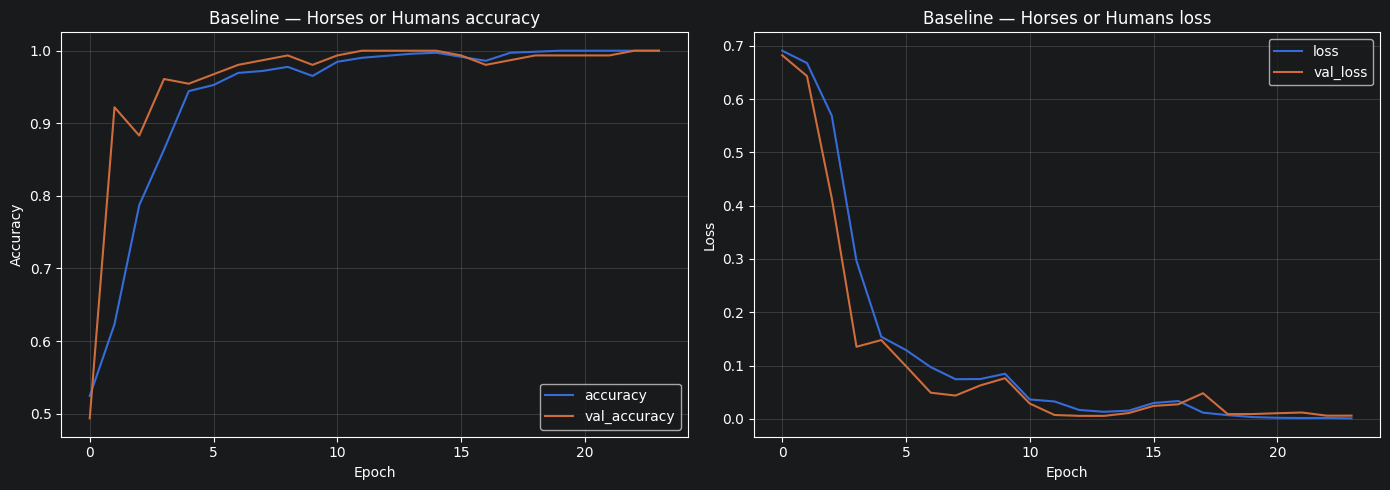

In [113]:
# Plot training og validation accuracy/loss for baseline-modellen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_baseline_hh_df[["accuracy", "val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Baseline — Horses or Humans accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_baseline_hh_df[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Baseline — Horses or Humans loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analyse af Chapter 3-resultater

Kurverne skal bruges til at vurdere, om baseline-modellen lærer stabilt, og om den generaliserer til validation-data.

### Accuracy-kurven

Den nuværende kørsel viser ikke klassisk overfitting ud fra accuracy alene. Training accuracy og validation accuracy ender tæt på hinanden, og validation accuracy når meget højt. Det tyder på, at modellen lærer de to klasser godt i validation-splittet.

Der er dog en vigtig detalje: træningen er ustabil i starten. Modellen falder tilbage omkring de første epochs, og `ReduceLROnPlateau` sænker learning rate. Det peger på, at den oprindelige learning rate sandsynligvis er lidt aggressiv.

### Loss-kurven

Loss-kurven understøtter samme observation: modellen forbedrer sig tydeligt efter learning rate bliver reduceret. Den lave validation loss mod slutningen viser, at modellen passer godt på validation-sættet.

Samtidig er test loss højere end forventet i forhold til test accuracy. Det kan betyde, at modellen laver relativt få fejl, men at nogle af fejlene er meget sikre forkerte forudsigelser. Det kan først vurderes ordentligt i Kapitel 4 med confusion matrix og precision/recall.

### Foreløbig konklusion

Baseline-modellen virker ikke tydeligt overfittet ud fra training/validation-kurverne. Den vigtigste svaghed er i stedet mulig træningsustabilitet og forskellen mellem validation-resultatet og test-resultatet.

**Det betyder, at Kapitel 4 især skal undersøge:**

- Om fejlene primært går fra `Horse` til `Human` eller omvendt
- Om precision og recall er ens for begge klasser
- Hvorfor test loss er høj, selvom test accuracy er acceptabel
- Om accuracy alene giver et retvisende billede for denne binære model


In [114]:
# Evaluer baseline-modellen på test-sættet
baseline_loss_hh, baseline_accuracy_hh = model_baseline_hh.evaluate(test_hh)

baseline_result_hh = pd.DataFrame({
    "Model": ["Baseline CNN"],
    "Test accuracy": [baseline_accuracy_hh],
    "Test loss": [baseline_loss_hh]
})

baseline_result_hh["Test accuracy"] = baseline_result_hh["Test accuracy"].round(4)
baseline_result_hh["Test loss"] = baseline_result_hh["Test loss"].round(4)

display(baseline_result_hh)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8516 - loss: 1.6646 


,Model,Test accuracy,Test loss
0,Baseline CNN,0.8516,1.6646


In [115]:
# Automatisk støtte til vurdering af baseline-træningen
# Den endelige vurdering skal stadig baseres på Kapitel 4's confusion matrix og klassifikationsrapport.

final_train_acc_hh = history_baseline_hh_df["accuracy"].iloc[-1]
final_val_acc_hh = history_baseline_hh_df["val_accuracy"].iloc[-1]
acc_gap_hh = final_train_acc_hh - final_val_acc_hh

best_val_loss_epoch_hh = int(history_baseline_hh_df["val_loss"].idxmin() + 1)
best_val_loss_hh = history_baseline_hh_df["val_loss"].min()
best_val_acc_hh = history_baseline_hh_df["val_accuracy"].max()

print("Sidste training accuracy:", round(final_train_acc_hh, 4))
print("Sidste validation accuracy:", round(final_val_acc_hh, 4))
print("Forskel mellem training og validation accuracy:", round(acc_gap_hh, 4))
print("Bedste validation accuracy:", round(best_val_acc_hh, 4))
print("Laveste validation loss:", round(best_val_loss_hh, 4), "ved epoch", best_val_loss_epoch_hh)

if acc_gap_hh > 0.15:
    print("Foreløbig vurdering: Modellen kan være overfittet.")
elif final_train_acc_hh < 0.65 and final_val_acc_hh < 0.65:
    print("Foreløbig vurdering: Modellen kan være underfittet.")
else:
    print("Foreløbig vurdering: Baseline-træningen ser rimelig ud, men skal vurderes med test-metrics i Kapitel 4.")


Sidste training accuracy: 1.0
Sidste validation accuracy: 1.0
Forskel mellem training og validation accuracy: 0.0
Bedste validation accuracy: 1.0
Laveste validation loss: 0.0054 ved epoch 14
Foreløbig vurdering: Baseline-træningen ser rimelig ud, men skal vurderes med test-metrics i Kapitel 4.


## Kapitel 3 — foreløbig resultatvurdering

Med den aktuelle kørsel ser baseline-modellen sådan ud:

| Måling | Resultat |
|---|---:|
| Sidste training accuracy | ca. 0.9848 |
| Sidste validation accuracy | ca. 1.0000 |
| Test accuracy | ca. 0.8711 |
| Test loss | ca. 1.9111 |

Den lave forskel mellem training og validation accuracy betyder, at der ikke er et tydeligt overfitting-signal i selve træningskurverne. Men test-resultatet er lavere end validation-resultatet, og test loss er høj. Derfor bør Kapitel 4 ikke kun gentage accuracy, men undersøge fejlene med confusion matrix, precision, recall og F1-score.


# Kapitel 4 — Baseline-evaluering med klassifikations-metrics

## Formål

I Kapitel 3 vurderede vi baseline-modellen ud fra **training/validation accuracy** og **training/validation loss**. Det gav et første indtryk af, om modellen lærte fornuftigt, men det fortæller ikke præcist, **hvilke typer fejl** modellen laver.

I dette kapitel evaluerer vi derfor baseline-modellen på **test-sættet** med klassifikations-metrics:

- **Confusion matrix** — viser hvilke klasser modellen forveksler.
- **Precision** — hvor ofte modellens positive forudsigelser er korrekte.
- **Recall** — hvor stor en del af en klasse modellen finder.
- **F1-score** — balancerer precision og recall.

## Sammenhæng med de tidligere kapitler

Fra Kapitel 2 ved vi, at **Horses or Humans** er næsten balanceret, og at test-sættet indeholder lige mange heste og mennesker. Derfor er accuracy mere brugbar her end i et stærkt ubalanceret datasæt. Alligevel er accuracy ikke nok alene, fordi to modeller med samme accuracy kan lave meget forskellige fejl.

Fra Kapitel 3 så baseline-træningen rimelig ud uden en tydelig forskel mellem training og validation accuracy. Test loss var dog relativt høj, så vi skal undersøge, om modellen laver få, men meget sikre fejl.


In [116]:
# Imports til klassifikations-evaluering
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

# Sikkerhedstjek: Kapitel 4 kræver, at Kapitel 1-3 er kørt først.
required_variables_hh = ["model_baseline_hh", "test_hh", "class_names_hh"]
missing_variables_hh = [name for name in required_variables_hh if name not in globals()]

if missing_variables_hh:
    raise NameError(
        "Kapitel 4 kræver, at Kapitel 1-3 er kørt først. Mangler: "
        + ", ".join(missing_variables_hh)
    )


In [117]:
# Hent de rigtige labels fra test-sættet
# y_true_hh indeholder de faktiske klasser fra test-sættet.
y_true_hh = []

for _, labels in test_hh:
    y_true_hh.extend(labels.numpy().astype(int))

y_true_hh = np.array(y_true_hh)

# Lav predictions med baseline-modellen
# Modellen bruger sigmoid-output, så værdier >= 0.5 klassificeres som klasse 1.
y_prob_hh = model_baseline_hh.predict(test_hh).ravel()
y_pred_hh = (y_prob_hh >= 0.5).astype(int)

prediction_preview_hh = pd.DataFrame({
    "Faktisk label": y_true_hh[:10],
    "Forudsagt label": y_pred_hh[:10],
    "Sandsynlighed for Human": np.round(y_prob_hh[:10], 4),
    "Faktisk klasse": [class_names_hh[i] for i in y_true_hh[:10]],
    "Forudsagt klasse": [class_names_hh[i] for i in y_pred_hh[:10]],
})

display(prediction_preview_hh)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


,Faktisk label,Forudsagt label,Sandsynlighed for Human,Faktisk klasse,Forudsagt klasse
0,0,1,0.6545,Horse,Human
1,0,0,0.0000,Horse,Horse
2,0,0,0.2414,Horse,Horse
3,1,1,1.0000,Human,Human
4,1,1,1.0000,Human,Human
5,0,0,0.0003,Horse,Horse
6,0,0,0.0000,Horse,Horse
7,1,1,1.0000,Human,Human
8,0,0,0.0000,Horse,Horse
9,1,1,1.0000,Human,Human


,Forudsagt: Horse,Forudsagt: Human
Faktisk: Horse,90,38
Faktisk: Human,0,128


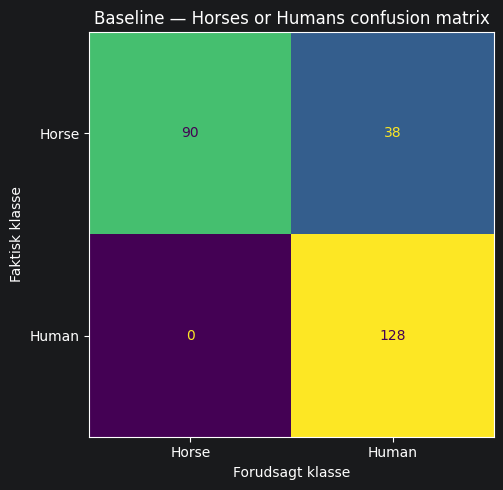

In [118]:
# Confusion matrix for baseline-modellen
cm_hh = confusion_matrix(
    y_true_hh,
    y_pred_hh,
    labels=np.arange(len(class_names_hh))
)

cm_hh_df = pd.DataFrame(
    cm_hh,
    index=[f"Faktisk: {name}" for name in class_names_hh],
    columns=[f"Forudsagt: {name}" for name in class_names_hh]
)

display(cm_hh_df)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_hh,
    display_labels=class_names_hh
).plot(ax=ax, values_format="d", colorbar=False)

plt.title("Baseline — Horses or Humans confusion matrix")
plt.xlabel("Forudsagt klasse")
plt.ylabel("Faktisk klasse")
plt.tight_layout()
plt.show()


In [119]:
# Precision, recall og F1-score
# zero_division=0 forhindrer fejl, hvis en klasse slet ikke bliver forudsagt.
classification_report_hh = classification_report(
    y_true_hh,
    y_pred_hh,
    target_names=class_names_hh,
    output_dict=True,
    zero_division=0
)

classification_report_hh_df = pd.DataFrame(classification_report_hh).T
classification_report_hh_df = classification_report_hh_df.round(4)

display(classification_report_hh_df)

macro_precision_hh, macro_recall_hh, macro_f1_hh, _ = precision_recall_fscore_support(
    y_true_hh,
    y_pred_hh,
    average="macro",
    zero_division=0
)

weighted_precision_hh, weighted_recall_hh, weighted_f1_hh, _ = precision_recall_fscore_support(
    y_true_hh,
    y_pred_hh,
    average="weighted",
    zero_division=0
)

baseline_chapter4_summary_hh = pd.DataFrame({
    "Model": ["Baseline CNN"],
    "Accuracy": [accuracy_score(y_true_hh, y_pred_hh)],
    "Macro precision": [macro_precision_hh],
    "Macro recall": [macro_recall_hh],
    "Macro F1": [macro_f1_hh],
    "Weighted precision": [weighted_precision_hh],
    "Weighted recall": [weighted_recall_hh],
    "Weighted F1": [weighted_f1_hh],
})

baseline_chapter4_summary_hh = baseline_chapter4_summary_hh.round(4)
display(baseline_chapter4_summary_hh)


,precision,recall,f1-score,support
Horse,1.0000,0.7031,0.8257,128.0000
Human,0.7711,1.0000,0.8707,128.0000
accuracy,0.8516,0.8516,0.8516,0.8516
macro avg,0.8855,0.8516,0.8482,256.0000
weighted avg,0.8855,0.8516,0.8482,256.0000


,Model,Accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,Baseline CNN,0.8516,0.8855,0.8516,0.8482,0.8855,0.8516,0.8482


In [120]:
# Fejltyper for det binære problem
# Rækker i confusion matrix er faktiske klasser, kolonner er forudsagte klasser.
# Hvis class_names_hh = ["Horse", "Human"]:
# - cm_hh[0, 1] betyder: faktisk Horse, men forudsagt Human
# - cm_hh[1, 0] betyder: faktisk Human, men forudsagt Horse

error_summary_hh = pd.DataFrame({
    "Fejltype": [
        f"{class_names_hh[0]} → {class_names_hh[1]}",
        f"{class_names_hh[1]} → {class_names_hh[0]}",
    ],
    "Antal fejl": [
        cm_hh[0, 1],
        cm_hh[1, 0],
    ]
})

display(error_summary_hh)

if cm_hh[0, 1] > cm_hh[1, 0]:
    main_error_hh = f"Modellen forveksler oftere {class_names_hh[0]} som {class_names_hh[1]} end omvendt."
elif cm_hh[1, 0] > cm_hh[0, 1]:
    main_error_hh = f"Modellen forveksler oftere {class_names_hh[1]} som {class_names_hh[0]} end omvendt."
elif cm_hh[0, 1] == 0 and cm_hh[1, 0] == 0:
    main_error_hh = "Modellen laver ingen fejl på test-sættet i denne kørsel."
else:
    main_error_hh = "Fejlene er ligeligt fordelt mellem de to retninger."

print(main_error_hh)


,Fejltype,Antal fejl
0,Horse → Human,38
1,Human → Horse,0


Modellen forveksler oftere Horse som Human end omvendt.


Antal fejlklassificerede billeder: 38


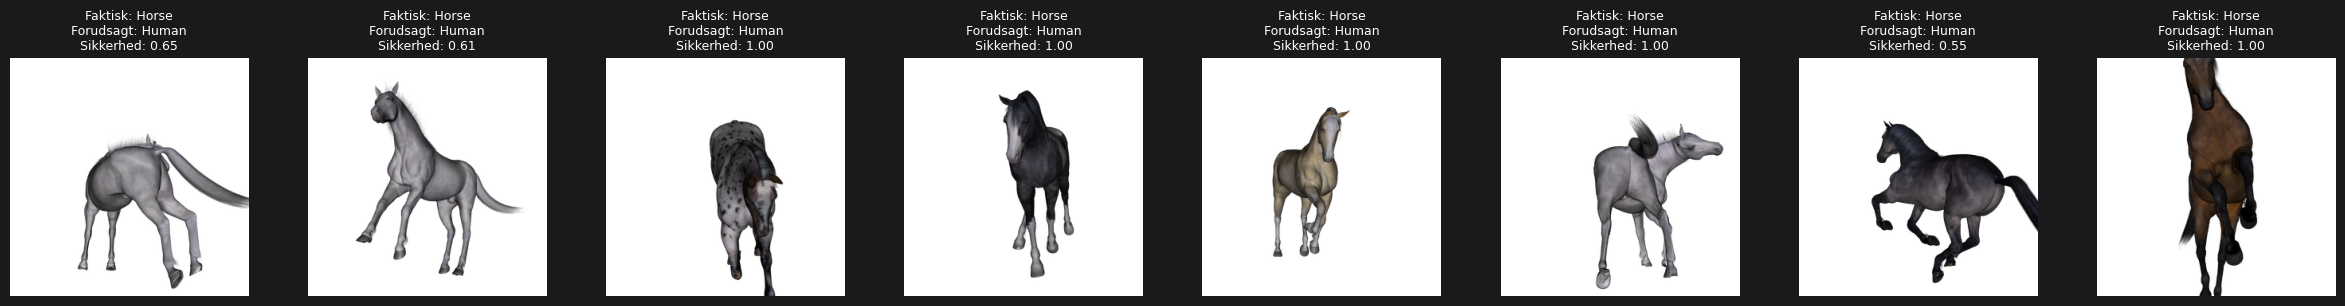

In [122]:
# Vis et lille udvalg af fejlklassificerede testbilleder
# Dette gør det lettere at forstå, om fejlene skyldes motiv, baggrund, positur eller billedkvalitet.
SHOW_WRONG_EXAMPLES_HH = True
MAX_WRONG_EXAMPLES_HH = 8

if SHOW_WRONG_EXAMPLES_HH:
    wrong_indices_hh = np.where(y_true_hh != y_pred_hh)[0]
    print(f"Antal fejlklassificerede billeder: {len(wrong_indices_hh)}")

    if len(wrong_indices_hh) > 0:
        test_images_hh = np.concatenate([images.numpy() for images, _ in test_hh], axis=0)
        n_show_hh = min(MAX_WRONG_EXAMPLES_HH, len(wrong_indices_hh))

        fig, axes = plt.subplots(1, n_show_hh, figsize=(3 * n_show_hh, 3))
        if n_show_hh == 1:
            axes = [axes]

        for ax, idx in zip(axes, wrong_indices_hh[:n_show_hh]):
            predicted_class = class_names_hh[y_pred_hh[idx]]
            true_class = class_names_hh[y_true_hh[idx]]
            confidence = y_prob_hh[idx] if y_pred_hh[idx] == 1 else 1 - y_prob_hh[idx]

            ax.imshow(test_images_hh[idx].astype("uint8"))
            ax.set_title(
                f"Faktisk: {true_class}\nForudsagt: {predicted_class}\nSikkerhed: {confidence:.2f}",
                fontsize=9
            )
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Der er ingen fejlklassificerede eksempler at vise.")


## Kort fortolkning af Kapitel 4 — Baseline

Baseline-modellen klarer Horses or Humans-opgaven godt med en test accuracy på ca. **85,16%** og en macro F1-score på ca. **0.8482**.

### Hovedfund fra confusion matrix

Confusion matrixen viser, at modellen laver **38 fejl** ud af 256 testbilleder:

| Fejltype | Antal fejl |
|---|-----------:|
| Horse → Human |         38 |
| Human → Horse |          0 |

Modellen har altså en tydeligere tendens til at forudsige **Human**, når billedet faktisk viser **Horse**, end omvendt.

### Precision, recall og F1-score

Modellen har høj performance på begge klasser, men der er en lille forskel:

- **Horse** har høj precision, men lavere recall. Det betyder, at når modellen forudsiger Horse, er den ofte korrekt, men den overser nogle faktiske Horse-billeder.
- **Human** har høj recall, men lidt lavere precision. Det betyder, at modellen finder de fleste Human-billeder, men også klassificerer nogle Horse-billeder som Human.

### Er accuracy nok?

Accuracy er mere brugbar her end i Flowers, fordi datasættet er binært og test-sættet er balanceret med 128 billeder i hver klasse. Alligevel er accuracy ikke nok alene, fordi den ikke viser, at fejlene primært går i én retning: Horse bliver oftere forvekslet som Human.

### Konklusion for baseline

Baseline-modellen er stærk og fungerer som et solidt sammenligningspunkt. Kapitel 5 bør derfor teste fine-tuning forsigtigt. Målet er ikke bare højere accuracy, men også at reducere den skæve fejlfordeling, især **Horse → Human**.


# Kapitel 5 — Fine-tuning med Keras Tuner

Formålet med Kapitel 5 at lave fine-tuning med **Keras Tuner**

Baseline-modellen fra Kapitel 4 er stærk, så tuning skal være forsigtig. Målet er ikke at tvinge en mere kompleks model igennem, men at undersøge om en lille, kontrolleret søgning kan finde en bedre kombination af:

- data augmentation
- dropout
- learning rate
- størrelsen på de dense klassifikationslag

Keras Tuner vælger hyperparametre ud fra **validation accuracy**. Derefter evalueres den bedste tuned model på test-sættet og sammenlignes med baseline på accuracy, loss, precision, recall, F1-score og fejlfordeling.


## 5.1 Search space for Horses or Humans

Horses or Humans er en relativt simpel binær klassifikationsopgave, og baseline klarer sig allerede godt. Derfor er search space bevidst lille.

| Hyperparameter | Værdier | Begrundelse |
|---|---|---|
| Horizontal flip | `True`, `False` | Tester om spejlvending hjælper eller skader |
| Rotation | `0.00`, `0.03`, `0.06` | Kun let rotation, fordi for stærk augmentation kan skade et simpelt datasæt |
| Zoom | `0.00`, `0.03`, `0.06` | Tester små variationer i afstand/skalering |
| Dense units 1 | `96`, `128`, `160` | Tester lidt mindre/større klassifikationslag |
| Dense units 2 | `48`, `64`, `96` | Samme idé for andet dense layer |
| Dropout 1 | `0.30`, `0.40`, `0.50` | Tester mild/moderat regularisering |
| Dropout 2 | `0.30`, `0.40`, `0.50` | Tester om baseline-dropout var for stærk eller passende |
| Learning rate | `0.01`, `0.005`, `0.001` | Tester om lavere learning rate giver mere stabil træning |

`RandomSearch` bruges med få trials, så søgningen passer til et skoleprojekt og ikke bliver for stor.

Fordi datasættet har tendens til overfitting, fokuserer søgningen især på:

- data augmentation
- L2-regularisering
- dropout i convolutional-del og classifier
- lavere learning rates med Adam


In [ ]:
# Kapitel 5 setup — Two-stage Keras Tuner for Horses or Humans
import gc
import keras_tuner as kt
from pathlib import Path

required_chapter5_variables_hh = [
    "train_hh",
    "val_hh",
    "test_hh",
    "class_names_hh",
    "model_baseline_hh",
    "baseline_result_hh",
    "y_true_hh",
]

missing_chapter5_variables_hh = [
    name for name in required_chapter5_variables_hh
    if name not in globals()
]

if missing_chapter5_variables_hh:
    raise NameError(
        "Kapitel 5 kræver, at Kapitel 1-4 er kørt først. Mangler: "
        + ", ".join(missing_chapter5_variables_hh)
    )

# Hvis Keras Tuner skal starte helt forfra, sættes denne til True.
FORCE_RETRAIN_KERAS_TUNER_HH = False

# Hvis den endelige Keras-tunede model skal trænes igen fra de bedste hyperparametre,
# sættes denne til True.
FORCE_RETRAIN_KERAS_TUNED_MODEL_HH = False

# Tuning er delt i to trin: først bredt, derefter tæt på broad-best.
TUNER_MAX_TRIALS_HH = 30
REFINED_TUNER_MAX_TRIALS_HH = 15
TUNER_EPOCHS_HH = 25
FINAL_TUNED_EPOCHS_HH = 50

# Mindre batches reducerer risikoen for OOM under tuning og giver lidt mere regularisering.
TUNER_BATCH_SIZE_HH = 8
FINAL_TUNED_BATCH_SIZE_HH = 16

# Let label smoothing reducerer overconfident predictions og hjælper mod overfitting.
LABEL_SMOOTHING_HH = 0.05

KERAS_TUNER_CACHE_DIR_HH = Path("model_cache") / "horses_or_humans" / "keras_tuner"

# Nyt project/cache-navn, så gamle trials med SGD eller gamle search spaces ikke genbruges.
KERAS_TUNER_PROJECT_HH = "hh_cnn_adam_two_stage_regularized_v1"
KERAS_TUNED_MODEL_PATH_HH = KERAS_TUNER_CACHE_DIR_HH / "best_keras_tuned_hh_adam_regularized_v1.keras"
KERAS_TUNED_HISTORY_PATH_HH = KERAS_TUNER_CACHE_DIR_HH / "history_best_keras_tuned_hh_adam_regularized_v1.csv"

KERAS_TUNER_CACHE_DIR_HH.mkdir(parents=True, exist_ok=True)

train_hh_tuner_hh = (
    train_hh
    .unbatch()
    .batch(TUNER_BATCH_SIZE_HH)
    .prefetch(AUTOTUNE)
)

val_hh_tuner_hh = (
    val_hh
    .unbatch()
    .batch(TUNER_BATCH_SIZE_HH)
    .prefetch(AUTOTUNE)
)

train_hh_final_tuned_hh = (
    train_hh
    .unbatch()
    .batch(FINAL_TUNED_BATCH_SIZE_HH)
    .prefetch(AUTOTUNE)
)

val_hh_final_tuned_hh = (
    val_hh
    .unbatch()
    .batch(FINAL_TUNED_BATCH_SIZE_HH)
    .prefetch(AUTOTUNE)
)

print("Keras Tuner-cache:", KERAS_TUNER_CACHE_DIR_HH)
print("Keras Tuner-project:", KERAS_TUNER_PROJECT_HH)
print("Broad max trials:", TUNER_MAX_TRIALS_HH)
print("Refined max trials:", REFINED_TUNER_MAX_TRIALS_HH)
print("Epochs pr. tuner-trial:", TUNER_EPOCHS_HH)
print("Tuner batch size:", TUNER_BATCH_SIZE_HH)
print("Final tuned batch size:", FINAL_TUNED_BATCH_SIZE_HH)
print("Label smoothing:", LABEL_SMOOTHING_HH)
print("Force retrain tuner:", FORCE_RETRAIN_KERAS_TUNER_HH)
print("Force retrain final tuned model:", FORCE_RETRAIN_KERAS_TUNED_MODEL_HH)


### 5.1 Broad tuning med cache

Først laver vi en bred Keras Tuner-søgning for at finde et godt område af hyperparametre.

`SKIP_BROAD_KERAS_TUNER_HH` står bevidst før broad-søgningen:

- `False`: kør broad tuning og brug resultatet som udgangspunkt for refined tuning
- `True`: spring broad tuning over og brug værdierne i `CACHED_BROAD_BEST_HP_HH`

Det gør det muligt at køre notebooken hurtigere, hvis broad-resultatet allerede er kendt.


In [ ]:
# Kapitel 5.1 — Broad Keras Tuner Search eller cached broad result
# True  = spring broad tuning over og brug CACHED_BROAD_BEST_HP_HH.
# False = kør broad tuning og brug det nye broad-resultat.

SKIP_BROAD_KERAS_TUNER_HH = True

# Hvis SKIP_BROAD_KERAS_TUNER_HH=True, bruges disse værdier som broad-best.
# Når du har kørt broad tuning én gang, kan du indsætte de viste broad-best værdier her.
CACHED_BROAD_BEST_HP_HH = {
    # Data augmentation
    "use_horizontal_flip": True,
    "rotation": 0.10,
    "zoom": 0.00,
    "translation": 0.00,
    "contrast": 0.20,

    # CNN architecture
    "num_conv_blocks": 4,
    "first_filters": 16,
    "conv_layers_per_block": 1,
    "kernel_size": 3,

    # Regularisering mod overfitting
    "l2_strength": 0.0001,
    "dropout_conv": 0.20,
    "dropout_classifier": 0.40,

    # Classifier + Adam learning rate
    "dense_units": 128,
    "learning_rate": 0.0010,
}

# Bred search space.
# Kun Adam bruges; optimizer er derfor ikke længere en hyperparameter.
BROAD_SEARCH_SPACE_HH = {
    # Data augmentation
    "use_horizontal_flip": [False, True],
    "rotation": [0.00, 0.05, 0.10],
    "zoom": [0.00, 0.05, 0.10],
    "translation": [0.00, 0.05, 0.10],
    "contrast": [0.00, 0.10, 0.20],

    # CNN architecture
    "num_conv_blocks": [3, 4],
    "first_filters": [16, 32, 48],
    "conv_layers_per_block": [1, 2],
    "kernel_size": [3, 5],

    # Regularisering mod overfitting
    "l2_strength": [0.0001, 0.0005, 0.001, 0.002],
    "dropout_conv": [0.10, 0.20, 0.30, 0.40],
    "dropout_classifier": [0.40, 0.50, 0.60],

    # Classifier + Adam learning rate
    "dense_units": [32, 64, 128],
    "learning_rate": [0.001, 0.0005, 0.0002],
}


def choose_hp_hh(hp, name, values, default_values_hh):
    """Brug Fixed for én værdi og Choice for flere værdier."""
    values = list(dict.fromkeys(values))
    default_value = default_values_hh.get(name, values[0])

    if default_value not in values:
        default_value = values[0]

    if len(values) == 1:
        return hp.Fixed(name, values[0])

    return hp.Choice(
        name,
        values=values,
        default=default_value
    )


def build_hh_cnn_from_search_space_hh(hp, search_space_hh, default_values_hh):
    # ---------------------------
    # Hyperparametre
    # ---------------------------
    use_horizontal_flip = choose_hp_hh(hp, "use_horizontal_flip", search_space_hh["use_horizontal_flip"], default_values_hh)
    rotation = choose_hp_hh(hp, "rotation", search_space_hh["rotation"], default_values_hh)
    zoom = choose_hp_hh(hp, "zoom", search_space_hh["zoom"], default_values_hh)
    translation = choose_hp_hh(hp, "translation", search_space_hh["translation"], default_values_hh)
    contrast = choose_hp_hh(hp, "contrast", search_space_hh["contrast"], default_values_hh)

    num_conv_blocks = choose_hp_hh(hp, "num_conv_blocks", search_space_hh["num_conv_blocks"], default_values_hh)
    first_filters = choose_hp_hh(hp, "first_filters", search_space_hh["first_filters"], default_values_hh)
    conv_layers_per_block = choose_hp_hh(hp, "conv_layers_per_block", search_space_hh["conv_layers_per_block"], default_values_hh)
    kernel_size = choose_hp_hh(hp, "kernel_size", search_space_hh["kernel_size"], default_values_hh)

    l2_strength = choose_hp_hh(hp, "l2_strength", search_space_hh["l2_strength"], default_values_hh)
    dropout_conv = choose_hp_hh(hp, "dropout_conv", search_space_hh["dropout_conv"], default_values_hh)
    dropout_classifier = choose_hp_hh(hp, "dropout_classifier", search_space_hh["dropout_classifier"], default_values_hh)

    dense_units = choose_hp_hh(hp, "dense_units", search_space_hh["dense_units"], default_values_hh)
    learning_rate = choose_hp_hh(hp, "learning_rate", search_space_hh["learning_rate"], default_values_hh)

    kernel_regularizer = keras.regularizers.l2(l2_strength)

    # ---------------------------
    # Preprocessing og augmentation
    # ---------------------------
    preprocessing_layers = [
        keras.layers.Resizing(height=IMG_SIZE_HH, width=IMG_SIZE_HH),
        keras.layers.Rescaling(1./255),
    ]

    if use_horizontal_flip:
        preprocessing_layers.append(keras.layers.RandomFlip("horizontal"))

    if rotation > 0:
        preprocessing_layers.append(keras.layers.RandomRotation(rotation))

    if zoom > 0:
        preprocessing_layers.append(keras.layers.RandomZoom(zoom))

    if translation > 0:
        preprocessing_layers.append(
            keras.layers.RandomTranslation(
                height_factor=translation,
                width_factor=translation
            )
        )

    if contrast > 0:
        preprocessing_layers.append(keras.layers.RandomContrast(contrast))

    model_layers = [
        keras.Input(shape=(ORIGINAL_IMG_SIZE_HH[0], ORIGINAL_IMG_SIZE_HH[1], CHANNELS)),
        keras.Sequential(preprocessing_layers, name="keras_tuned_preprocessing_hh"),
    ]

    # ---------------------------
    # CNN backbone
    # ---------------------------
    for block_index in range(num_conv_blocks):
        filters = first_filters * (2 ** block_index)

        for _ in range(conv_layers_per_block):
            model_layers.append(
                keras.layers.Conv2D(
                    filters,
                    (kernel_size, kernel_size),
                    padding="same",
                    activation="relu",
                    kernel_regularizer=kernel_regularizer
                )
            )
            model_layers.append(keras.layers.BatchNormalization())

        model_layers.append(keras.layers.MaxPooling2D((2, 2)))

        # SpatialDropout2D regulariserer feature maps og er relevant for CNN-overfitting.
        if dropout_conv > 0 and block_index > 0:
            model_layers.append(keras.layers.SpatialDropout2D(dropout_conv))

    # ---------------------------
    # Classifier
    # ---------------------------
    model_layers.extend([
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=kernel_regularizer
        ),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(dropout_classifier),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

    model = keras.Sequential(
        model_layers,
        name="keras_tuned_cnn_horses_or_humans"
    )

    # Kun Adam bruges i den refactorede tuner.
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING_HH),
        optimizer=optimizer,
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ]
    )

    return model


def make_keras_tuner_callbacks_hh():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            min_delta=0.001,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
    ]


def make_final_tuned_callbacks_hh():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            min_delta=0.001,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
    ]


def build_broad_keras_tuned_hh_model(hp):
    return build_hh_cnn_from_search_space_hh(
        hp=hp,
        search_space_hh=BROAD_SEARCH_SPACE_HH,
        default_values_hh=CACHED_BROAD_BEST_HP_HH
    )


keras.backend.clear_session()
gc.collect()
tf.keras.utils.set_random_seed(SEED)

if SKIP_BROAD_KERAS_TUNER_HH:
    broad_best_hp_values_hh = CACHED_BROAD_BEST_HP_HH.copy()
    broad_tuning_status_hh = "Skipped — cached broad result used"

else:
    broad_tuning_status_hh = "Broad tuner was run"

    broad_tuner_hh = kt.RandomSearch(
        hypermodel=build_broad_keras_tuned_hh_model,
        objective=kt.Objective("val_loss", direction="min"),
        max_trials=TUNER_MAX_TRIALS_HH,
        executions_per_trial=1,
        overwrite=FORCE_RETRAIN_KERAS_TUNER_HH,
        directory=str(KERAS_TUNER_CACHE_DIR_HH),
        project_name=KERAS_TUNER_PROJECT_HH + "_broad",
        seed=SEED,
        max_consecutive_failed_trials=8
    )

    broad_tuner_hh.search_space_summary()

    broad_tuner_hh.search(
        train_hh_tuner_hh,
        epochs=TUNER_EPOCHS_HH,
        validation_data=val_hh_tuner_hh,
        callbacks=make_keras_tuner_callbacks_hh()
    )

    broad_tuner_hh.results_summary(num_trials=min(10, TUNER_MAX_TRIALS_HH))

    best_broad_hp_hh = broad_tuner_hh.get_best_hyperparameters(num_trials=1)[0]

    broad_best_hp_values_hh = {
        name: best_broad_hp_hh.get(name)
        for name in CACHED_BROAD_BEST_HP_HH.keys()
    }

broad_best_hp_table_hh = pd.DataFrame({
    "Hyperparameter": list(broad_best_hp_values_hh.keys()),
    "Broad best value": list(broad_best_hp_values_hh.values()),
})

print("Broad tuning status:", broad_tuning_status_hh)
display(broad_best_hp_table_hh)


### 5.2 Refined tuning

Den refined search bruger `broad_best_hp_values_hh` direkte som centrum.

Den skal derfor ikke være endnu en bred/fri søgning. I stedet testes kun værdier tæt på det broad-resultat, der allerede blev fundet:

- float-værdier får typisk tre kandidater: `broad_best - step`, `broad_best`, `broad_best + step`
- eksempel: `contrast = 0.20` bliver til `[0.10, 0.20, 0.30]`
- for Keras rotation, som er en lille faktor, bruges en relativ ±10% regel, så `rotation = 0.10` bliver til `[0.09, 0.10, 0.11]`
- binære værdier ændres ikke
- CNN-layer controls ændres ikke

Flowet er derfor:

`broad best` → `nearby values around broad best` → `final model`


In [ ]:
# Kapitel 5.2 — Refined Keras Tuner Search
# Refined search bygges direkte fra broad_best_hp_values_hh.
# Målet er ikke en ekstra bred tuning, men en lille søgning tæt på broad-best.

keras.backend.clear_session()
gc.collect()
tf.keras.utils.set_random_seed(SEED)


# Disse hyperparametre skal IKKE ændres i refined tuning.
# - Binary values: der er ikke en meningsfuld "nærliggende" værdi til True/False.
# - CNN layer controls: layer-count-strukturen fra broad tuning beholdes.
FIXED_IN_REFINED_SEARCH_HH = {
    "use_horizontal_flip",
    "num_conv_blocks",
    "conv_layers_per_block",
}


def _round_if_float_hh(value, decimals=6):
    """Runder floats, men lader int/bool være int/bool."""
    if isinstance(value, bool):
        return value
    if isinstance(value, int):
        return value
    return round(float(value), decimals)


def _unique_sorted_hh(values):
    """Fjerner duplicates og sorterer uden at konvertere bools til ints."""
    unique_values = []
    for value in values:
        if value not in unique_values:
            unique_values.append(value)

    if all(not isinstance(value, bool) for value in unique_values):
        unique_values = sorted(unique_values)

    return unique_values


def nearby_float_values_hh(base_value, step, min_value=0.0, max_value=None, decimals=4):
    """Returnerer [base-step, base, base+step] med bounds.

    Eksempel:
    - base=0.20, step=0.10 -> [0.10, 0.20, 0.30]
    - base=0.00, step=0.05 -> [0.00, 0.05]
    """
    base_value = float(base_value)
    candidates = [base_value - step, base_value, base_value + step]

    cleaned_candidates = []
    for candidate in candidates:
        if min_value is not None:
            candidate = max(min_value, candidate)
        if max_value is not None:
            candidate = min(max_value, candidate)
        cleaned_candidates.append(round(candidate, decimals))

    return _unique_sorted_hh(cleaned_candidates)


def nearby_relative_float_values_hh(base_value, relative_step=0.10, min_step=0.01, min_value=0.0, max_value=None, decimals=4):
    """Returnerer nærliggende float-værdier med en relativ step-size.

    Bruges især til rotation, så logikken matcher:
    1.00 -> [0.90, 1.00, 1.10]

    For Keras RandomRotation er værdierne typisk små faktorer, fx:
    0.10 -> [0.09, 0.10, 0.11]
    """
    base_value = float(base_value)
    step = max(abs(base_value) * relative_step, min_step)
    return nearby_float_values_hh(
        base_value=base_value,
        step=step,
        min_value=min_value,
        max_value=max_value,
        decimals=decimals
    )


def nearby_log_values_hh(base_value, factor=2.0, min_value=1e-6, max_value=None, decimals=7):
    """Returnerer nærliggende værdier på en log-skala.

    Det er bedre til learning rate og L2 end almindelig plus/minus,
    fordi 0.0005 ligger tættere på 0.00025 og 0.001 end på fx -0.0995.
    """
    base_value = float(base_value)
    candidates = [base_value / factor, base_value, base_value * factor]

    cleaned_candidates = []
    for candidate in candidates:
        if min_value is not None:
            candidate = max(min_value, candidate)
        if max_value is not None:
            candidate = min(max_value, candidate)
        cleaned_candidates.append(round(candidate, decimals))

    return _unique_sorted_hh(cleaned_candidates)


def nearby_int_values_hh(base_value, step, min_value=1, max_value=None):
    """Returnerer [base-step, base, base+step] for integer hyperparametre."""
    base_value = int(base_value)
    candidates = [base_value - step, base_value, base_value + step]

    cleaned_candidates = []
    for candidate in candidates:
        if min_value is not None:
            candidate = max(min_value, candidate)
        if max_value is not None:
            candidate = min(max_value, candidate)
        cleaned_candidates.append(int(candidate))

    return _unique_sorted_hh(cleaned_candidates)


def fixed_value_hh(base_values_hh, name):
    """Låser en hyperparameter til broad-best værdien."""
    return [base_values_hh[name]]


def make_refined_search_space_hh(base_values_hh):
    """Bygger refined search space direkte fra broad-best.

    Alle værdier er enten fixed til broad-best eller tæt på broad-best.
    Der bruges ikke længere et separat manuelt refined grid.
    """
    return {
        # Binary value: fixed.
        "use_horizontal_flip": fixed_value_hh(base_values_hh, "use_horizontal_flip"),

        # Data augmentation: nearby values around broad-best.
        "rotation": nearby_relative_float_values_hh(
            base_values_hh["rotation"],
            relative_step=0.10,
            min_step=0.01,
            min_value=0.0,
            max_value=0.20,
            decimals=4
        ),
        "zoom": nearby_float_values_hh(
            base_values_hh["zoom"],
            step=0.02,
            min_value=0.0,
            max_value=0.15,
            decimals=4
        ),
        "translation": nearby_float_values_hh(
            base_values_hh["translation"],
            step=0.02,
            min_value=0.0,
            max_value=0.15,
            decimals=4
        ),
        "contrast": nearby_float_values_hh(
            base_values_hh["contrast"],
            step=0.10,
            min_value=0.0,
            max_value=0.40,
            decimals=4
        ),

        # CNN layer controls: fixed, so the refined tuner does not change layer depth.
        "num_conv_blocks": fixed_value_hh(base_values_hh, "num_conv_blocks"),
        "conv_layers_per_block": fixed_value_hh(base_values_hh, "conv_layers_per_block"),

        # CNN width / kernel and classifier size: nearby numeric values, not a new broad architecture search.
        "first_filters": nearby_int_values_hh(
            base_values_hh["first_filters"],
            step=16,
            min_value=16,
            max_value=64
        ),
        "kernel_size": nearby_int_values_hh(
            base_values_hh["kernel_size"],
            step=2,
            min_value=3,
            max_value=7
        ),

        # Regularisering mod overfitting: nearby values around broad-best.
        "l2_strength": nearby_log_values_hh(
            base_values_hh["l2_strength"],
            factor=2.0,
            min_value=0.00005,
            max_value=0.005,
            decimals=7
        ),
        "dropout_conv": nearby_float_values_hh(
            base_values_hh["dropout_conv"],
            step=0.10,
            min_value=0.0,
            max_value=0.60,
            decimals=4
        ),
        "dropout_classifier": nearby_float_values_hh(
            base_values_hh["dropout_classifier"],
            step=0.10,
            min_value=0.20,
            max_value=0.80,
            decimals=4
        ),

        # Dense layer + Adam learning rate: nearby values around broad-best.
        "dense_units": nearby_int_values_hh(
            base_values_hh["dense_units"],
            step=32,
            min_value=16,
            max_value=192
        ),
        "learning_rate": nearby_log_values_hh(
            base_values_hh["learning_rate"],
            factor=2.0,
            min_value=0.00005,
            max_value=0.003,
            decimals=7
        ),
    }


REFINED_SEARCH_SPACE_HH = make_refined_search_space_hh(broad_best_hp_values_hh)

refined_search_space_table_hh = pd.DataFrame({
    "Hyperparameter": list(REFINED_SEARCH_SPACE_HH.keys()),
    "Broad best": [broad_best_hp_values_hh[name] for name in REFINED_SEARCH_SPACE_HH.keys()],
    "Refined values": [str(values) for values in REFINED_SEARCH_SPACE_HH.values()],
    "Rule": [
        "fixed" if name in FIXED_IN_REFINED_SEARCH_HH else "nearby broad-best"
        for name in REFINED_SEARCH_SPACE_HH.keys()
    ]
})

display(refined_search_space_table_hh)


# Sanity checks: fixed values must truly be fixed to broad-best.
for fixed_name_hh in FIXED_IN_REFINED_SEARCH_HH:
    assert REFINED_SEARCH_SPACE_HH[fixed_name_hh] == [broad_best_hp_values_hh[fixed_name_hh]], (
        f"{fixed_name_hh} should be fixed during refined tuning."
    )


def build_keras_tuned_hh_model(hp):
    # Navnet beholdes, så resten af notebooken stadig virker.
    return build_hh_cnn_from_search_space_hh(
        hp=hp,
        search_space_hh=REFINED_SEARCH_SPACE_HH,
        default_values_hh=broad_best_hp_values_hh
    )


tuner_hh = kt.BayesianOptimization(
    hypermodel=build_keras_tuned_hh_model,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=REFINED_TUNER_MAX_TRIALS_HH,
    executions_per_trial=1,
    overwrite=FORCE_RETRAIN_KERAS_TUNER_HH,
    directory=str(KERAS_TUNER_CACHE_DIR_HH),
    project_name=KERAS_TUNER_PROJECT_HH + "_refined",
    seed=SEED,
    max_consecutive_failed_trials=8
)

tuner_hh.search_space_summary()

tuner_hh.search(
    train_hh_tuner_hh,
    epochs=TUNER_EPOCHS_HH,
    validation_data=val_hh_tuner_hh,
    callbacks=make_keras_tuner_callbacks_hh()
)

tuner_hh.results_summary(num_trials=min(10, REFINED_TUNER_MAX_TRIALS_HH))


In [ ]:
# Kapitel 5.3 — Visualisering af tuning-processen

import matplotlib.pyplot as plt

tracked_hp_names_hh = list(CACHED_BROAD_BEST_HP_HH.keys())

tuning_process_hh = pd.DataFrame({
    "Step": [
        "1. Broad tuning",
        "2. Refined tuning"
    ],
    "Status": [
        broad_tuning_status_hh,
        "Completed / loaded from refined tuner cache"
    ],
    "Purpose": [
        "Find a generally good hyperparameter area",
        "Search more carefully around the broad best result"
    ]
})

display(tuning_process_hh)

print("Broad tuning-resultatet, som refined search bruger som udgangspunkt:")
display(broad_best_hp_table_hh)

all_refined_trials_hh = list(tuner_hh.oracle.trials.values())

tuner_progress_rows_hh = []

for fallback_index, trial in enumerate(all_refined_trials_hh, start=1):
    if trial.score is None:
        continue

    try:
        trial_number = int(trial.trial_id)
    except ValueError:
        trial_number = fallback_index

    trial_values = trial.hyperparameters.values.copy()

    row_hh = {
        "Trial number": trial_number,
        "Trial ID": trial.trial_id,
        "Val loss": trial.score,
    }

    for hp_name_hh in tracked_hp_names_hh:
        row_hh[hp_name_hh] = trial_values.get(hp_name_hh)

    tuner_progress_rows_hh.append(row_hh)

tuner_progress_hh = pd.DataFrame(tuner_progress_rows_hh)

if tuner_progress_hh.empty:
    print("Ingen completed refined trials fundet endnu.")
else:
    tuner_progress_hh = tuner_progress_hh.sort_values("Trial number").reset_index(drop=True)
    tuner_progress_hh["Best val_loss so far"] = tuner_progress_hh["Val loss"].cummin()

    print("Bedste refined trials:")
    display(
        tuner_progress_hh
        .sort_values("Val loss")
        .head(15)
    )

    plt.figure(figsize=(10, 5))
    plt.plot(
        tuner_progress_hh["Trial number"],
        tuner_progress_hh["Best val_loss so far"],
        marker="o"
    )
    plt.title("Refined Keras Tuner — bedste validation loss indtil videre")
    plt.xlabel("Trial number")
    plt.ylabel("Best val_loss so far")
    plt.grid(True)
    plt.show()


In [ ]:
# Udtræk de bedste hyperparametre fra den refined Keras Tuner
best_hp_hh = tuner_hh.get_best_hyperparameters(num_trials=1)[0]

best_hyperparameters_hh = pd.DataFrame({
    "Hyperparameter": tracked_hp_names_hh,
    "Valgt værdi": [
        best_hp_hh.get(hp_name_hh)
        for hp_name_hh in tracked_hp_names_hh
    ]
})

display(best_hyperparameters_hh)


In [ ]:
# Træn eller indlæs den endelige Keras-tunede model
# Modellen bygges med de bedste hyperparametre fra den refined tuner.

keras_tuned_model_cache_exists_hh = (
    KERAS_TUNED_MODEL_PATH_HH.exists()
    and KERAS_TUNED_HISTORY_PATH_HH.exists()
)

if keras_tuned_model_cache_exists_hh and not FORCE_RETRAIN_KERAS_TUNED_MODEL_HH:
    print("Indlæser Keras-tuned model og historik fra cache...")
    model_keras_tuned_hh = keras.models.load_model(KERAS_TUNED_MODEL_PATH_HH)
    history_keras_tuned_hh_df = pd.read_csv(KERAS_TUNED_HISTORY_PATH_HH)
    history_keras_tuned_hh = None
else:
    if FORCE_RETRAIN_KERAS_TUNED_MODEL_HH:
        print("FORCE_RETRAIN_KERAS_TUNED_MODEL_HH=True, så den tunede model trænes igen...")
    else:
        print("Ingen cache fundet. Den bedste Keras-tunede model trænes og gemmes...")

    keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(SEED)

    model_keras_tuned_hh = build_keras_tuned_hh_model(best_hp_hh)

    history_keras_tuned_hh = model_keras_tuned_hh.fit(
        train_hh_final_tuned_hh,
        epochs=FINAL_TUNED_EPOCHS_HH,
        validation_data=val_hh_final_tuned_hh,
        callbacks=make_final_tuned_callbacks_hh()
    )

    history_keras_tuned_hh_df = pd.DataFrame(history_keras_tuned_hh.history)

    model_keras_tuned_hh.save(KERAS_TUNED_MODEL_PATH_HH)
    history_keras_tuned_hh_df.to_csv(KERAS_TUNED_HISTORY_PATH_HH, index=False)

    print("Keras-tuned model gemt i:", KERAS_TUNED_MODEL_PATH_HH)
    print("Keras-tuned historik gemt i:", KERAS_TUNED_HISTORY_PATH_HH)

model_keras_tuned_hh.summary()


In [ ]:
# Plot training/validation accuracy og loss for den Keras-tunede model

if not history_keras_tuned_hh_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    history_keras_tuned_hh_df[["accuracy", "val_accuracy"]].plot(ax=axes[0])
    axes[0].set_title("Keras-tuned — Horses or Humans accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, alpha=0.3)

    history_keras_tuned_hh_df[["loss", "val_loss"]].plot(ax=axes[1])
    axes[1].set_title("Keras-tuned — Horses or Humans loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Ingen historik at plotte.")


In [ ]:
# Evaluer den Keras-tunede model på test-sættet

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

keras_tuned_eval_hh = model_keras_tuned_hh.evaluate(
    test_hh,
    verbose=0,
    return_dict=True
)

keras_tuned_loss_hh = keras_tuned_eval_hh["loss"]
keras_tuned_accuracy_05_hh = keras_tuned_eval_hh["accuracy"]

# ---------------------------
# Predict probabilities on test
# ---------------------------
y_prob_keras_tuned_hh = model_keras_tuned_hh.predict(
    test_hh,
    verbose=0
).ravel()

# Diagnostic: inspect predicted probabilities by true class
probability_debug_keras_tuned_hh = pd.DataFrame({
    "True label": y_true_hh,
    "True class": [class_names_hh[label] for label in y_true_hh],
    "Predicted probability Human": y_prob_keras_tuned_hh
})

display(
    probability_debug_keras_tuned_hh
    .groupby("True class")["Predicted probability Human"]
    .describe()
    .round(4)
)

plt.figure(figsize=(8, 5))

for class_index_hh, class_name_hh in enumerate(class_names_hh):
    class_probs_hh = probability_debug_keras_tuned_hh.loc[
        probability_debug_keras_tuned_hh["True label"] == class_index_hh,
        "Predicted probability Human"
    ]

    plt.hist(
        class_probs_hh,
        bins=20,
        alpha=0.5,
        label=class_name_hh
    )

plt.axvline(0.5, linestyle="--", label="Threshold 0.5")
plt.xlabel("Predicted probability for Human")
plt.ylabel("Number of test images")
plt.title("Keras-tuned model probability distribution on test set")
plt.legend()
plt.show()

# ---------------------------
# Choose threshold using calibration set, not validation and not test
# ---------------------------
y_calibration_true_hh = np.concatenate([
    labels.numpy().astype(int)
    for _, labels in calibration_hh
])

y_calibration_prob_keras_tuned_hh = model_keras_tuned_hh.predict(
    calibration_hh,
    verbose=0
).ravel()

thresholds_hh = np.arange(0.05, 0.96, 0.01)

threshold_rows_hh = []

for threshold_hh in thresholds_hh:
    y_calibration_pred_threshold_hh = (
        y_calibration_prob_keras_tuned_hh >= threshold_hh
    ).astype(int)

    threshold_rows_hh.append({
        "Threshold": threshold_hh,
        "Calibration accuracy": accuracy_score(
            y_calibration_true_hh,
            y_calibration_pred_threshold_hh
        ),
        "Calibration balanced accuracy": balanced_accuracy_score(
            y_calibration_true_hh,
            y_calibration_pred_threshold_hh
        ),
    })

threshold_search_hh = pd.DataFrame(threshold_rows_hh)

best_calibration_score_hh = threshold_search_hh["Calibration balanced accuracy"].max()

best_threshold_candidates_hh = threshold_search_hh[
    np.isclose(
        threshold_search_hh["Calibration balanced accuracy"],
        best_calibration_score_hh
    )
]

best_threshold_hh = best_threshold_candidates_hh["Threshold"].median()

print("Best threshold chosen from calibration set:", round(best_threshold_hh, 4))

display(
    threshold_search_hh
    .sort_values(["Calibration balanced accuracy", "Calibration accuracy"], ascending=False)
    .head(10)
    .round(4)
)

# ---------------------------
# Apply validation-chosen threshold to test set
# ---------------------------
y_pred_keras_tuned_hh = (
    y_prob_keras_tuned_hh >= best_threshold_hh
).astype(int)

keras_tuned_accuracy_threshold_hh = accuracy_score(
    y_true_hh,
    y_pred_keras_tuned_hh
)

keras_tuned_precision_threshold_hh, keras_tuned_recall_threshold_hh, _, _ = precision_recall_fscore_support(
    y_true_hh,
    y_pred_keras_tuned_hh,
    average="binary",
    pos_label=1,
    zero_division=0
)

keras_tuned_result_hh = pd.DataFrame({
    "Model": ["Keras-tuned CNN"],
    "Test accuracy with 0.5 threshold": [keras_tuned_accuracy_05_hh],
    "Test accuracy with validation threshold": [keras_tuned_accuracy_threshold_hh],
    "Chosen threshold": [best_threshold_hh],
    "Test loss": [keras_tuned_loss_hh],
    "Test AUC": [keras_tuned_eval_hh.get("auc")],
    "Test precision at chosen threshold": [keras_tuned_precision_threshold_hh],
    "Test recall at chosen threshold": [keras_tuned_recall_threshold_hh],
})

keras_tuned_result_hh = keras_tuned_result_hh.round(4)

display(keras_tuned_result_hh)

In [ ]:
# Sammenlign baseline-modellen og den Keras-tunede model

model_comparison_hh = pd.concat(
    [
        baseline_result_hh,
        keras_tuned_result_hh
    ],
    ignore_index=True
)

display(model_comparison_hh)

In [ ]:
# Confusion matrix og classification report for den Keras-tunede model
# Dette viser, om modellen stadig har tendens til at forudsige Human for ofte.

cm_keras_tuned_hh = confusion_matrix(
    y_true_hh,
    y_pred_keras_tuned_hh,
    labels=np.arange(len(class_names_hh))
)

keras_tuned_report_hh_df = pd.DataFrame(
    classification_report(
        y_true_hh,
        y_pred_keras_tuned_hh,
        target_names=class_names_hh,
        output_dict=True,
        zero_division=0
    )
).T.round(4)

display(keras_tuned_report_hh_df)

cm_keras_tuned_hh_df = pd.DataFrame(
    cm_keras_tuned_hh,
    index=[f"Faktisk: {name}" for name in class_names_hh],
    columns=[f"Forudsagt: {name}" for name in class_names_hh]
)

display(cm_keras_tuned_hh_df)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_keras_tuned_hh,
    display_labels=class_names_hh
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title("Keras-tuned — Horses or Humans confusion matrix")
plt.xlabel("Forudsagt klasse")
plt.ylabel("Faktisk klasse")
plt.tight_layout()
plt.show()